# Original unknown-$R_p$ workflow: hybrid SciPy and Pyomo fitting

This tutorial starts from the original measured vial-bottom temperature series. Both backends share LyoPRONTO's legacy inverse-temperature preprocessing, which derives cake length $L_{ck}$ [cm] and product resistance $R_p$ [cm$^2$ hr Torr/g]. SciPy `curve_fit` and Pyomo then fit the same observations to

$$R_p = R_0 + \frac{A_1 L_{ck}}{1 + A_2 L_{ck}}.$$

This is explicitly a **hybrid** Pyomo workflow: Pyomo replaces only the nonlinear parameter fit. A direct Pyomo inverse model for measured $T_{bot}(t)$ is outside the current model boundary. The figures retain the original resistance, temperature, pressure/flux, and percent-dried diagnostics; only the resistance-fit panel compares SciPy and Pyomo because both fits share the same legacy inverse trajectory.

In [1]:
from pathlib import Path
import sys
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np

repo_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from examples.original_workflow_parity import (
    build_unknown_rp_pyomo_model,
    fit_unknown_rp_scipy,
    preprocess_unknown_rp,
    pyomo_ipopt_status,
    solve_unknown_rp_pyomo_model,
)

In [2]:
preprocessing_start = perf_counter()
trajectory, product_resistance = preprocess_unknown_rp()
preprocessing_elapsed_s = perf_counter() - preprocessing_start
scipy_fit_start = perf_counter()
scipy_fit = fit_unknown_rp_scipy(product_resistance)
scipy_fit_elapsed_s = perf_counter() - scipy_fit_start
print(f"Legacy preprocessing: {len(product_resistance)} observations")
print(f"Legacy inverse preprocessing wall time: {preprocessing_elapsed_s:.4f} s")
print(f"SciPy R0/A1/A2: {scipy_fit.R0:.8f}, {scipy_fit.A1:.8f}, {scipy_fit.A2:.8f}")
print(f"SciPy sum of squared Rp residuals: {scipy_fit.objective:.8f}")
print(f"SciPy curve_fit wall time: {scipy_fit_elapsed_s:.4f} s")

Legacy preprocessing: 453 observations
Legacy inverse preprocessing wall time: 0.0216 s
SciPy R0/A1/A2: 0.02089280, 7.84331782, 0.50813991
SciPy sum of squared Rp residuals: 58.10059774
SciPy curve_fit wall time: 0.0007 s


In [3]:
pyomo_ready, pyomo_message = pyomo_ipopt_status()
print(pyomo_message)
pyomo_build_elapsed_s = None
pyomo_solve_elapsed_s = None
if pyomo_ready:
    pyomo_build_start = perf_counter()
    pyomo_model = build_unknown_rp_pyomo_model(product_resistance)
    pyomo_build_elapsed_s = perf_counter() - pyomo_build_start
    pyomo_solve_start = perf_counter()
    pyomo_fit = solve_unknown_rp_pyomo_model(pyomo_model)
    pyomo_solve_elapsed_s = perf_counter() - pyomo_solve_start
else:
    pyomo_fit = None
if pyomo_fit is not None:
    print(f"Pyomo status: {pyomo_fit.solver_status}/{pyomo_fit.termination_condition}")
    if pyomo_fit.success:
        print(f"Pyomo R0/A1/A2: {pyomo_fit.R0:.8f}, {pyomo_fit.A1:.8f}, {pyomo_fit.A2:.8f}")
        print(f"Pyomo sum of squared Rp residuals: {pyomo_fit.objective:.8f}")
    else:
        print(pyomo_fit.message)
    print(f"Pyomo model construction wall time: {pyomo_build_elapsed_s:.4f} s")
    print(f"Pyomo solver wall time: {pyomo_solve_elapsed_s:.4f} s")

Pyomo and IPOPT are available.


Pyomo status: ok/optimal
Pyomo R0/A1/A2: 0.02089182, 7.84333423, 0.50814499
Pyomo sum of squared Rp residuals: 58.10059774
Pyomo model construction wall time: 0.0112 s
Pyomo solver wall time: 0.2015 s


The solver-backed regression allows $2\times10^{-5}$ relative or absolute parameter error and $10^{-6}$ absolute objective error. These tolerances cover local NLP termination while remaining much tighter than the scale of the fitted parameters. Reported wall times are single executions in the active environment, not benchmarks. Legacy inverse preprocessing, SciPy fitting, Pyomo model construction, and the IPOPT solve are separated so the shared preprocessing cost is not attributed to either fitting backend.

In [4]:
if pyomo_fit is not None and pyomo_fit.success:
    np.testing.assert_allclose(pyomo_fit.as_array(), scipy_fit.as_array(), rtol=2e-5, atol=2e-5)
    assert abs(pyomo_fit.objective - scipy_fit.objective) <= 1e-6
    assert pyomo_build_elapsed_s >= 0.0
    assert pyomo_solve_elapsed_s >= 0.0
    print("SciPy/Pyomo parameter and objective tolerances satisfied.")
elif pyomo_fit is not None:
    print(f"SciPy/Pyomo parity skipped: {pyomo_fit.message}")
assert preprocessing_elapsed_s >= 0.0
assert scipy_fit_elapsed_s >= 0.0

SciPy/Pyomo parameter and objective tolerances satisfied.


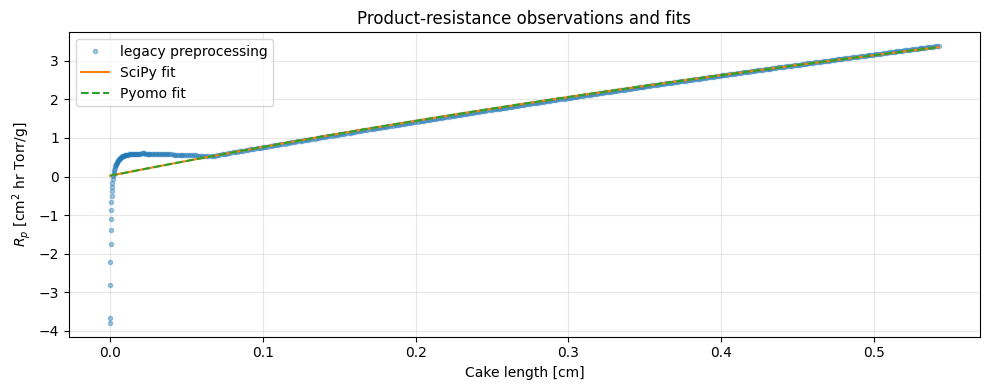

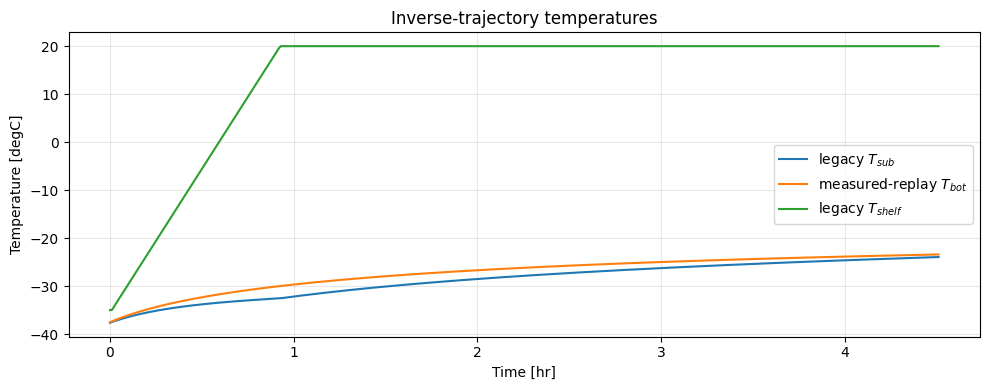

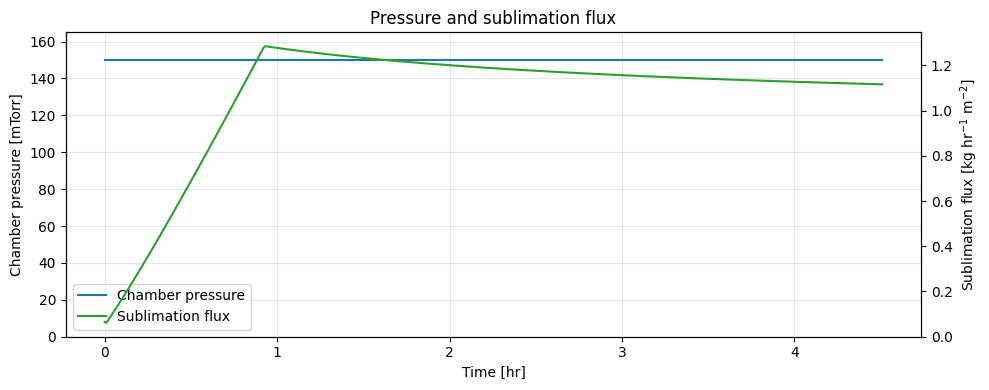

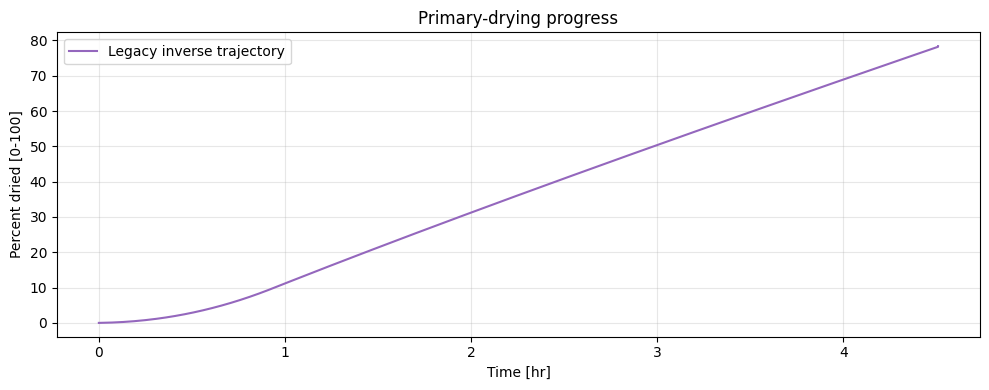

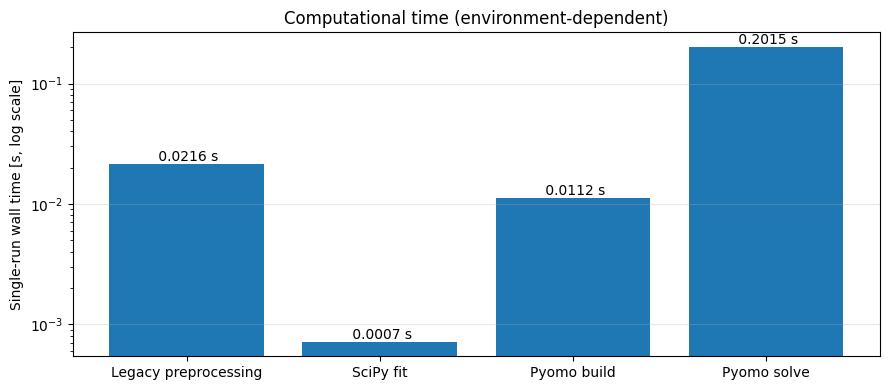

In [5]:
length = product_resistance[:, 1]
observed_rp = product_resistance[:, 2]
scipy_curve = scipy_fit.R0 + length * scipy_fit.A1 / (1 + length * scipy_fit.A2)
fig_resistance, resistance_axis = plt.subplots(figsize=(10, 4))
resistance_axis.plot(length, observed_rp, ".", alpha=0.4, label="legacy preprocessing")
resistance_axis.plot(length, scipy_curve, label="SciPy fit")
if pyomo_fit is not None and pyomo_fit.success:
    pyomo_curve = pyomo_fit.R0 + length * pyomo_fit.A1 / (1 + length * pyomo_fit.A2)
    resistance_axis.plot(length, pyomo_curve, "--", label="Pyomo fit")
resistance_axis.set(xlabel="Cake length [cm]", ylabel="$R_p$ [cm$^2$ hr Torr/g]", title="Product-resistance observations and fits")
resistance_axis.grid(alpha=0.3)
resistance_axis.legend()
fig_resistance.tight_layout()

fig_temperature, temperature_axis = plt.subplots(figsize=(10, 4))
temperature_axis.plot(trajectory[:, 0], trajectory[:, 1], label=r"legacy $T_{sub}$")
temperature_axis.plot(trajectory[:, 0], trajectory[:, 2], label=r"measured-replay $T_{bot}$")
temperature_axis.plot(trajectory[:, 0], trajectory[:, 3], label=r"legacy $T_{shelf}$")
temperature_axis.set(xlabel="Time [hr]", ylabel="Temperature [degC]", title="Inverse-trajectory temperatures")
temperature_axis.grid(alpha=0.3)
temperature_axis.legend()
fig_temperature.tight_layout()

fig_transport, pressure_axis = plt.subplots(figsize=(10, 4))
flux_axis = pressure_axis.twinx()
pressure_axis.plot(trajectory[:, 0], trajectory[:, 4], color="C0", label="Chamber pressure")
flux_axis.plot(trajectory[:, 0], trajectory[:, 5], color="C2", label="Sublimation flux")
pressure_axis.set(xlabel="Time [hr]", ylabel="Chamber pressure [mTorr]", title="Pressure and sublimation flux")
pressure_axis.set_ylim(0.0, 1.1 * trajectory[:, 4].max())
flux_axis.set_ylabel(r"Sublimation flux [kg hr$^{-1}$ m$^{-2}$]")
pressure_axis.grid(alpha=0.3)
transport_lines = pressure_axis.lines + flux_axis.lines
pressure_axis.legend(transport_lines, [line.get_label() for line in transport_lines])
fig_transport.tight_layout()

fig_dried, dried_axis = plt.subplots(figsize=(10, 4))
dried_axis.plot(trajectory[:, 0], trajectory[:, 6], color="C4", label="Legacy inverse trajectory")
dried_axis.set(xlabel="Time [hr]", ylabel="Percent dried [0-100]", title="Primary-drying progress")
dried_axis.grid(alpha=0.3)
dried_axis.legend()
fig_dried.tight_layout()

timing_labels = ["Legacy preprocessing", "SciPy fit"]
timing_values = [preprocessing_elapsed_s, scipy_fit_elapsed_s]
if pyomo_build_elapsed_s is not None and pyomo_solve_elapsed_s is not None:
    timing_labels.extend(["Pyomo build", "Pyomo solve"])
    timing_values.extend([pyomo_build_elapsed_s, pyomo_solve_elapsed_s])
fig_timing, timing_axis = plt.subplots(figsize=(9, 4))
timing_axis.bar(timing_labels, timing_values)
timing_axis.set_yscale("log")
timing_axis.set(ylabel="Single-run wall time [s, log scale]", title="Computational time (environment-dependent)")
timing_axis.grid(axis="y", alpha=0.3)
for index, value in enumerate(timing_values):
    timing_axis.text(index, value, f" {value:.4f} s", ha="center", va="bottom")
fig_timing.tight_layout()